In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/clean_it_jobs.csv")

In [2]:
#Phân tích 1: Thành phố tuyển IT nhiều nhất
top_city = df["city"].value_counts().head(10)

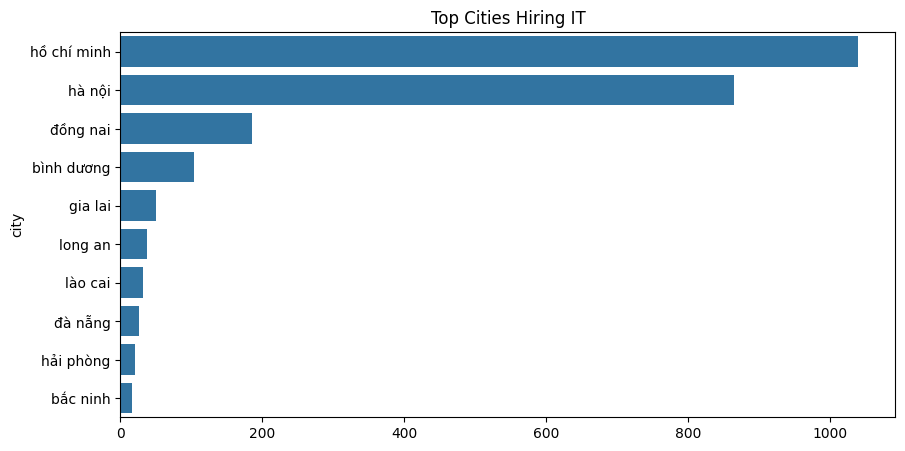

In [3]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=top_city.values,
    y=top_city.index
)

plt.title("Top Cities Hiring IT")
plt.show()

In [4]:
#Phân tích 2: Top vị trí tuyển dụng
top_jobs = df["job_title"].value_counts().head(15)

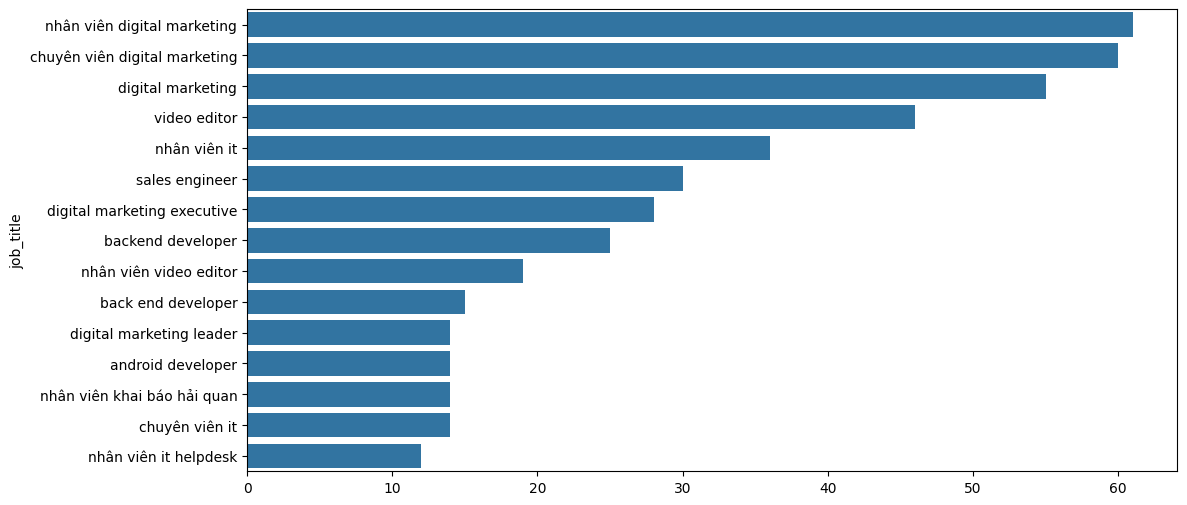

In [5]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_jobs.values,
    y=top_jobs.index
)

plt.show()

In [6]:
#Phân tích 3: Top kĩ năng
skills = (
    df["skills"]
    .str.lower()
    .str.split(",")
    .explode()
)

In [7]:
top_skills = skills.value_counts().head(20)

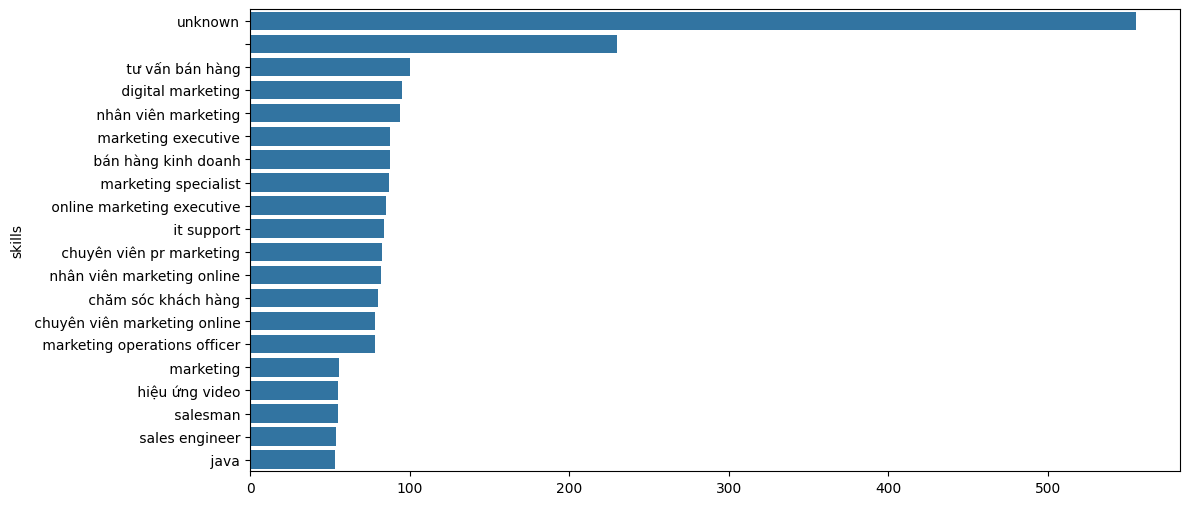

In [8]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_skills.values,
    y=top_skills.index
)

plt.show()

In [9]:
#Phân tích 4: Lương trung bình theo vị trí
salary_job = (
    df.groupby("job_title")
    ["avg_salary"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

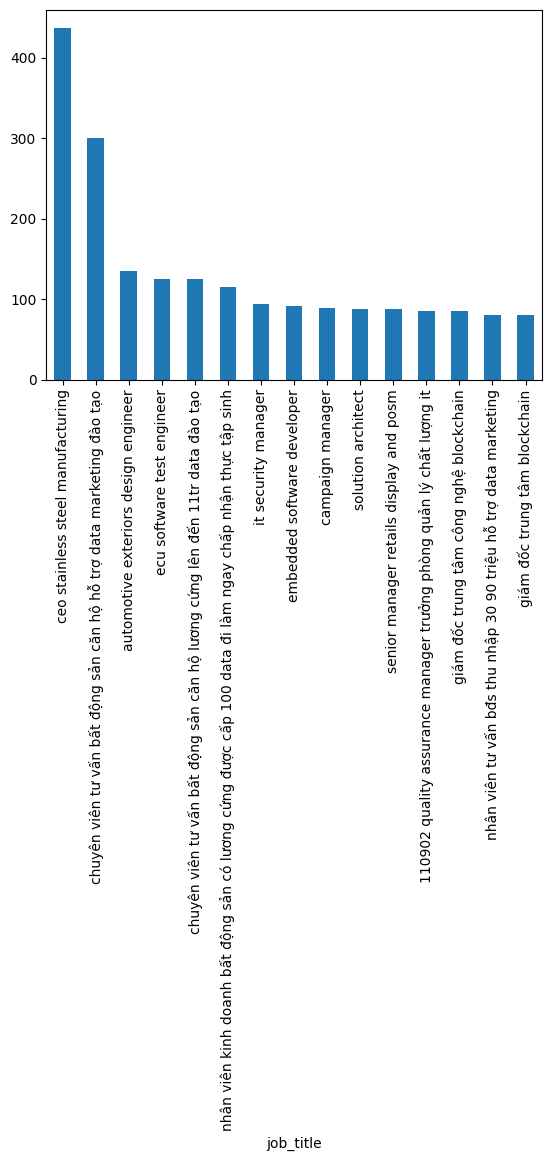

In [10]:
salary_job.plot(kind="bar")
plt.xticks(rotation=90)
plt.show()

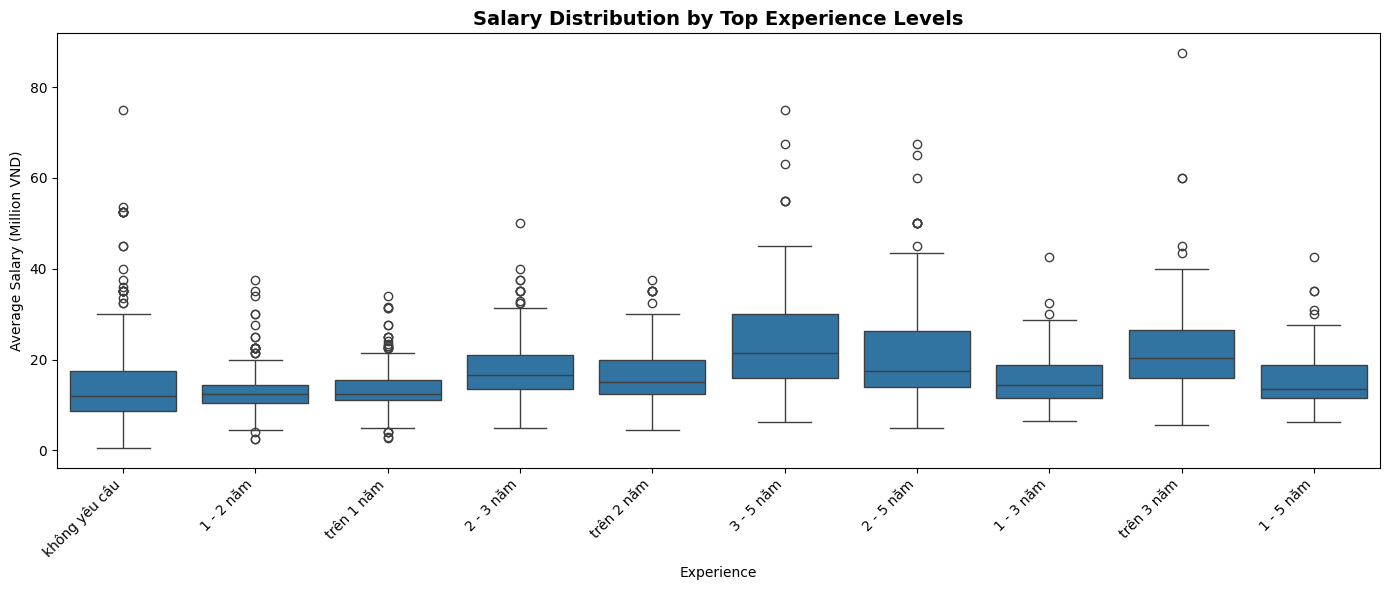

In [16]:
#Phân tích 5: Mối quan hệ giữa kinh nghiệm và lương

# Lấy 10 mức kinh nghiệm phổ biến nhất
top_exp = df["experience"].value_counts().head(10).index

df_plot = df[
    (df["avg_salary"] < 100) &
    (df["experience"].isin(top_exp))
]

plt.figure(figsize=(14,6))

sns.boxplot(
    data=df_plot,
    x="experience",
    y="avg_salary",
    order=top_exp
)

plt.xticks(rotation=45, ha="right")

plt.title(
    "Salary Distribution by Top Experience Levels",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Experience")
plt.ylabel("Average Salary (Million VND)")

plt.tight_layout()
plt.show()

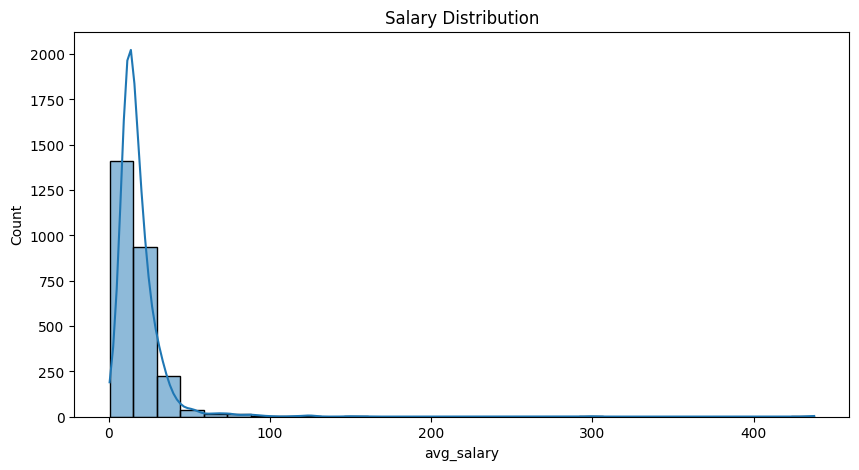

In [17]:
#Phân tích phân bố lương
plt.figure(figsize=(10,5))

sns.histplot(
    df["avg_salary"],
    bins=30,
    kde=True
)

plt.title("Salary Distribution")
plt.show()

In [24]:
#Lương theo thành phố
df_salary_city = df[
    (df["avg_salary"] > 0) &
    (df["avg_salary"] < 100)
]

In [25]:
#Tính lương trung bình
salary_city = (
    df_salary_city
    .groupby("city")["avg_salary"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

salary_city

,avg_salary
city,
hokkaido,91.000000
nhật bản,59.583333
nước ngoài,50.000000
q1,45.000000
toà nhà tng 54a nguyễn chí thanh,30.000000
quảng ninh,29.520833
bà rịa vũng tàu,23.406250
vietnam,23.000000
quảng ngãi,22.500000


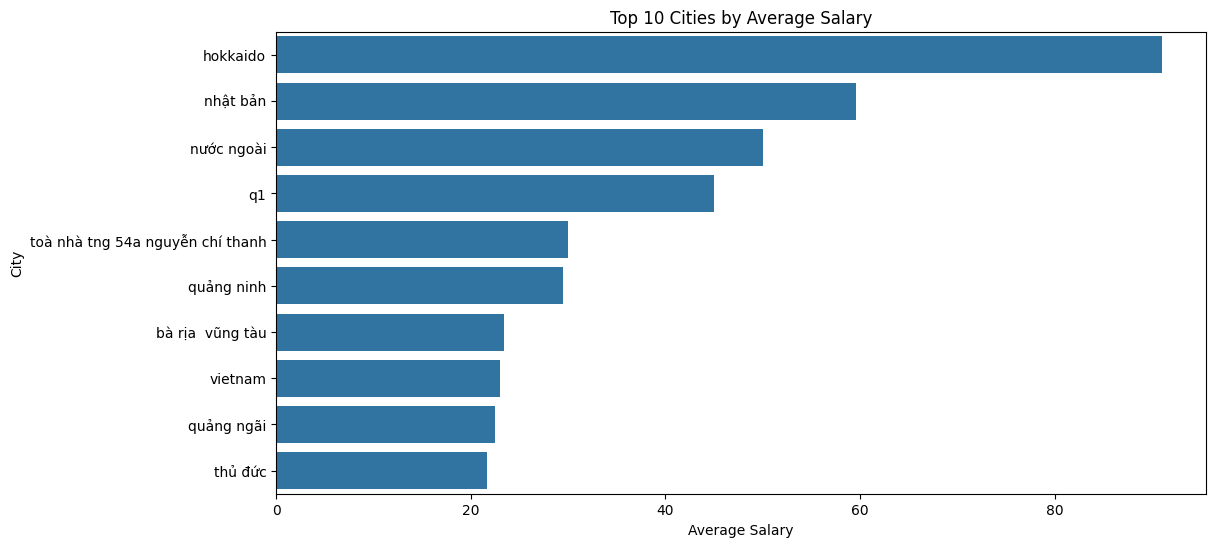

In [26]:
#Vẽ biểu đồ
plt.figure(figsize=(12,6))

sns.barplot(
    x=salary_city.values,
    y=salary_city.index
)

plt.title("Top 10 Cities by Average Salary")
plt.xlabel("Average Salary")
plt.ylabel("City")

plt.show()

In [27]:
#Phân tích kĩ năng theo vị trí
#1. Lọc kĩ năng
da_jobs = df[
    df["job_title"]
    .str.contains(
        "data analyst",
        case=False,
        na=False
    )
]

In [28]:
#Tách kĩ năng
da_jobs = df[
    df["job_title"]
    .str.contains(
        "data analyst",
        case=False,
        na=False
    )
]

In [29]:
#Top kỹ năng
top_skills = skills.value_counts().head(15)

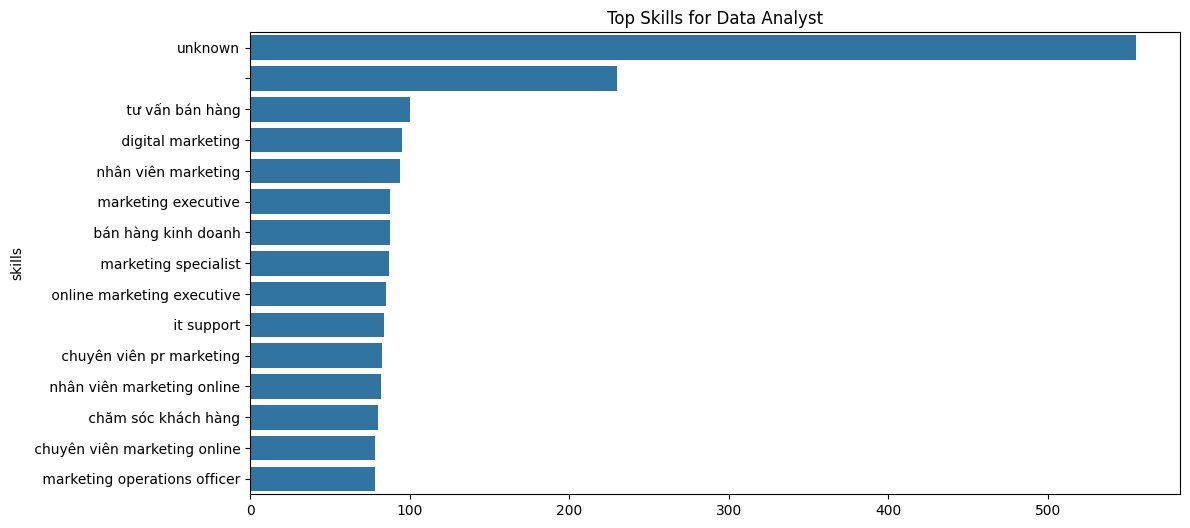

In [30]:
#Vẽ
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_skills.values,
    y=top_skills.index
)

plt.title(
    "Top Skills for Data Analyst"
)

plt.show()

In [31]:
#Skill Pair Analysis
from itertools import combinations
from collections import Counter

In [32]:
pair_counter = Counter()

for skills in df["skills"].dropna():

    skill_list = [
        s.strip().lower()
        for s in skills.split(",")
    ]

    for pair in combinations(
        sorted(set(skill_list)),
        2
    ):
        pair_counter[pair] += 1

In [33]:
pair_counter.most_common(20)

[(('', 'bán hàng kinh doanh'), 87),
 (('marketing executive', 'nhân viên marketing'), 85),
 (('marketer', 'marketing executive'), 84),
 (('marketer', 'nhân viên marketing'), 84),
 (('marketing specialist', 'nhân viên marketing'), 83),
 (('chuyên viên pr marketing', 'marketer'), 82),
 (('chuyên viên pr marketing', 'marketing executive'), 82),
 (('marketer', 'marketing specialist'), 82),
 (('marketing executive', 'online marketing executive'), 82),
 (('chuyên viên pr marketing', 'marketing specialist'), 81),
 (('chuyên viên pr marketing', 'nhân viên marketing'), 81),
 (('chuyên viên pr marketing', 'online marketing executive'), 81),
 (('marketer', 'online marketing executive'), 81),
 (('marketing executive', 'marketing specialist'), 81),
 (('marketing specialist', 'online marketing executive'), 81),
 (('nhân viên marketing', 'online marketing executive'), 81),
 (('marketing specialist', 'nhân viên marketing online'), 80),
 (('nhân viên marketing', 'nhân viên marketing online'), 80),
 (('

In [34]:
pairs_df = pd.DataFrame(
    pair_counter.most_common(20),
    columns=["pair", "count"]
)

pairs_df

,pair,count
0,"(, bán hàng kinh doanh)",87
1,"(marketing executive, nhân viên marketing)",85
2,"(marketer, marketing executive)",84
3,"(marketer, nhân viên marketing)",84
4,"(marketing specialist, nhân viên marketing)",83
5,"(chuyên viên pr marketing, marketer)",82
6,"(chuyên viên pr marketing, marketing executive)",82
7,"(marketer, marketing specialist)",82
8,"(marketing executive, online marketing executive)",82
9,"(chuyên viên pr marketing, marketing specialist)",81


In [35]:
#Heatmap kĩ năng
all_skills = (
    df["skills"]
    .dropna()
    .str.lower()
    .str.split(",")
    .explode()
)

top10 = (
    all_skills
    .value_counts()
    .head(10)
    .index
)

In [36]:
import numpy as np

matrix = pd.DataFrame(
    0,
    index=top10,
    columns=top10
)

In [37]:
for skills in df["skills"].dropna():

    skill_list = [
        s.strip().lower()
        for s in skills.split(",")
    ]

    skill_list = [
        s for s in skill_list
        if s in top10
    ]

    for s1 in skill_list:
        for s2 in skill_list:
            if s1 != s2:
                matrix.loc[s1,s2] += 1

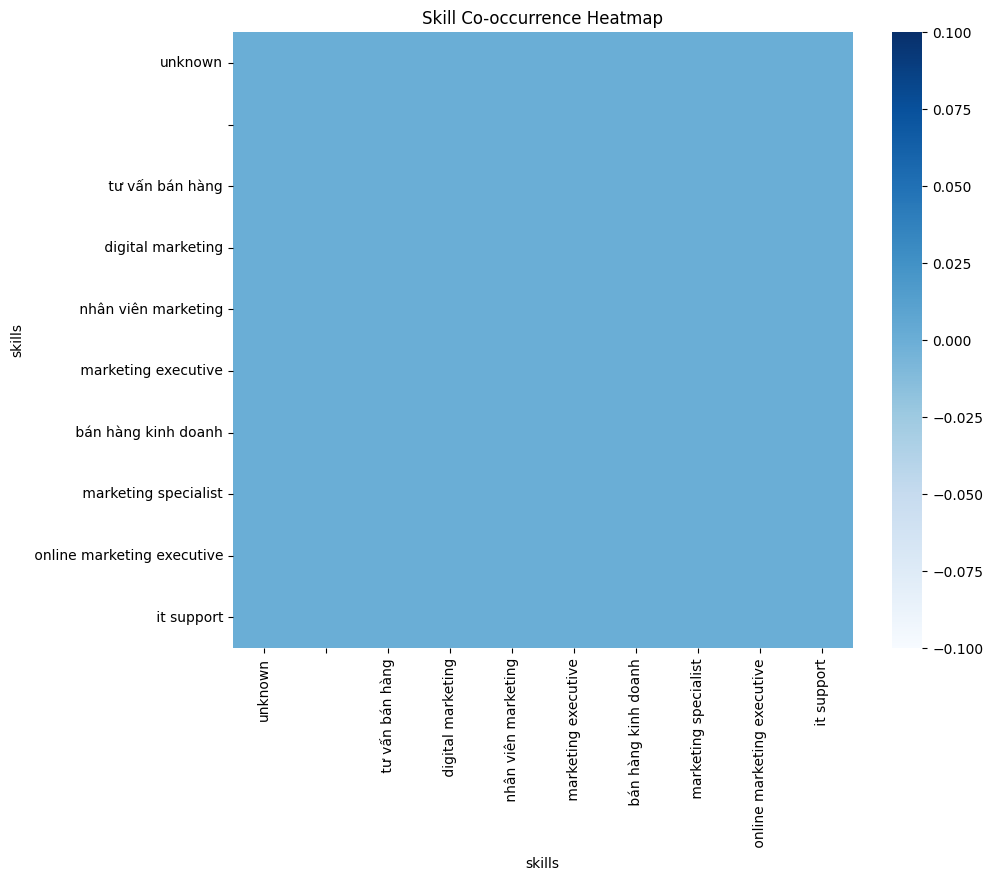

In [38]:
plt.figure(figsize=(10,8))

sns.heatmap(
    matrix,
    cmap="Blues"
)

plt.title(
    "Skill Co-occurrence Heatmap"
)

plt.show()

In [39]:
#Lương theo kỹ năng
skills_list = [
    "python",
    "sql",
    "java",
    "react",
    "docker",
    "aws"
]

In [40]:
salary_skill = {}

for skill in skills_list:

    temp = df[
        df["skills"]
        .str.lower()
        .str.contains(
            skill,
            na=False
        )
    ]

    salary_skill[skill] = (
        temp["avg_salary"]
        .mean()
    )

In [41]:
#DataFrame
salary_skill_df = pd.DataFrame(
    salary_skill.items(),
    columns=[
        "skill",
        "salary"
    ]
)

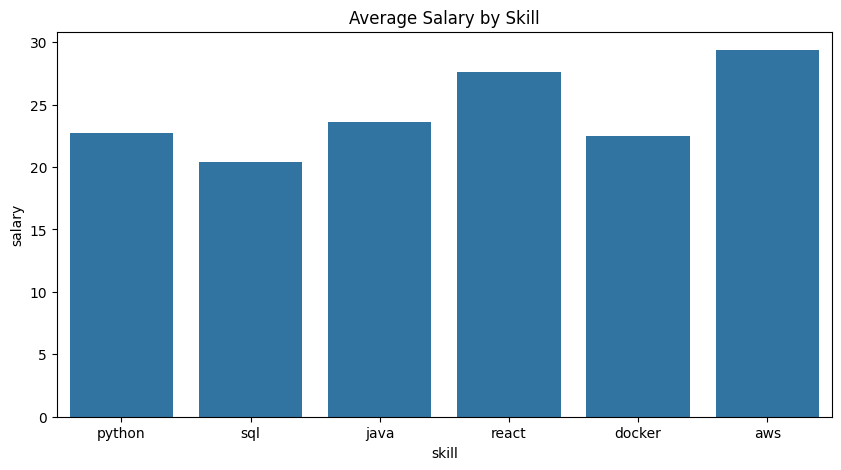

In [42]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=salary_skill_df,
    x="skill",
    y="salary"
)

plt.title(
    "Average Salary by Skill"
)

plt.show()

In [44]:
#Số lượng kỹ năng và mức lương
skill_count = (
    df["skills"]
    .str.lower()
    .str.split(",")
    .apply(len)
)

In [45]:
df[
    ["skill_count","avg_salary"]
].head()

,skill_count,avg_salary
0,8,19.5
1,6,12.5
2,4,8.5
3,1,55.0
4,11,18.0


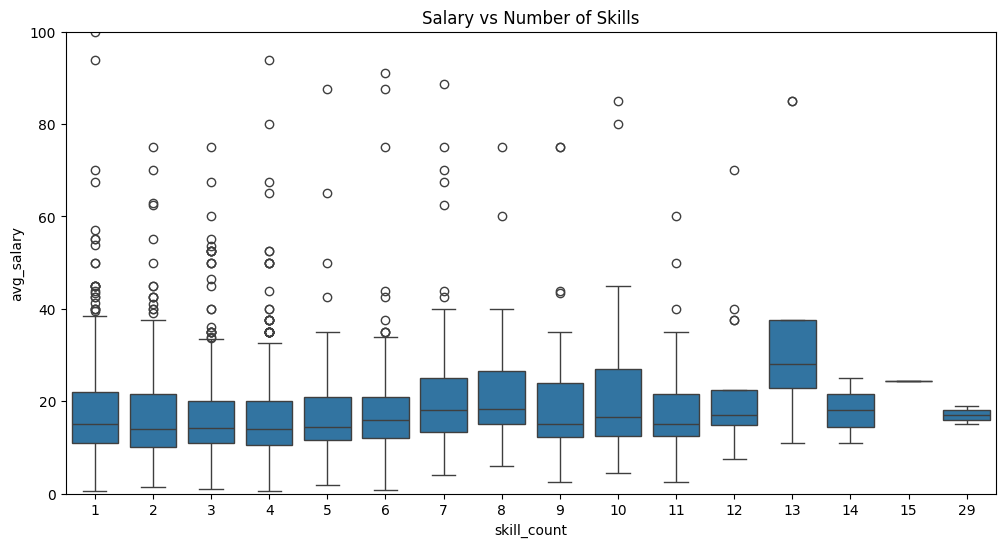

In [46]:
#Boxplot
plt.figure(figsize=(12,6))

sns.boxplot(
    data=df,
    x="skill_count",
    y="avg_salary"
)

plt.ylim(0,100)

plt.title(
    "Salary vs Number of Skills"
)

plt.show()

In [47]:
#Correlation Analysis
numeric_df = df[
    [
        "salary_min",
        "salary_max",
        "avg_salary",
        "skill_count"
    ]
]

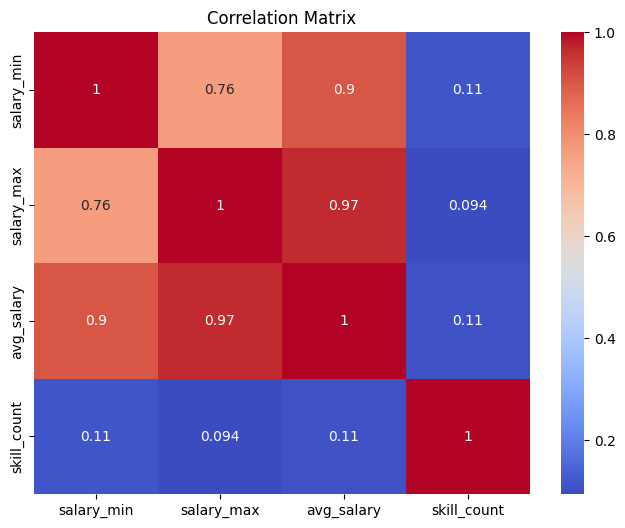

In [48]:
#Heatmap tương quan
corr = numeric_df.corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title(
    "Correlation Matrix"
)

plt.show()